# 04 · Gauge matchup — empirical vertical alignment (PHASE 2)

**Not part of V1.** Matches gauge *stage* to ICESat-2 pass WSE and estimates
`alignment_constant_m = median(H_EVRS_ICESat − stage)`.

This is **not** a Baltic→EVRS datum offset: it also absorbs the gauge zero
elevation and systematic ICESat/EGG2015 bias.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent / 'src'))
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from kakhovka_altimetry.config import load_config
from kakhovka_altimetry.io import read_parquet
cfg = load_config()


In [2]:
from kakhovka_altimetry.gauges import load_gauge_observations
from kakhovka_altimetry.matchup import build_matchups
from kakhovka_altimetry.datum import estimate_empirical_alignment, summarise
passes = read_parquet(cfg.pass_levels_parquet)
obs = load_gauge_observations(cfg)
m = build_matchups(passes, obs, cfg)
m.head()

,datetime,rgt,beam,transect,period,station_id,WSE_ICESat_evrs_m,icesat_nmad_m,n_points,stage_m,WSE_gauge_baltic_m,alignment_residual_m,adopted_constant_m,time_difference_hours,distance_to_gauge_km,gauge_interpolated
0,2020-01-09 03:48:40.307702016+00:00,205,gt1l,205_gt1l,PRE_BREACH,80959,15.919799,0.039022,94,3.526352,15.526352,12.393447,NaN,2.188803,10.604572,True
1,2020-01-09 03:48:40.307702016+00:00,205,gt1l,205_gt1l,PRE_BREACH,80961,15.919799,0.039022,94,3.352704,15.352704,12.567096,NaN,2.188803,36.635883,True
2,2020-01-09 03:48:40.307702016+00:00,205,gt1l,205_gt1l,PRE_BREACH,80963,15.919799,0.039022,94,3.421824,15.421824,12.497975,NaN,2.188803,44.960215,True
3,2020-01-09 03:48:40.307702016+00:00,205,gt1l,205_gt1l,PRE_BREACH,80964,15.919799,0.039022,94,3.426352,15.426352,12.493447,NaN,2.188803,59.405110,True
4,2020-01-09 03:48:44.919202048+00:00,205,gt2l,205_gt2l,PRE_BREACH,80959,15.740569,0.012776,22,3.526354,15.526354,12.214215,NaN,2.187522,29.850408,True


In [3]:
align = estimate_empirical_alignment(m, cfg)
print(summarise(align)); align

alignment_constant_m = +12.344 m (NMAD 0.060 m, n=1422, 95% CI [+12.340, +12.348]). Empirical vertical alignment constant -- incorporates the gauge zero, the Baltic-1977 -> EVRS datum difference and systematic ICESat/EGG2015 bias; not a pure datum offset.


,station,n_matchups,alignment_constant_m,nmad_m,ci95_low_m,ci95_high_m,period,reference
0,80959,347,12.273718,0.073296,12.264477,12.282960,PRE_BREACH,ATL13+gauge
1,80961,181,12.396004,0.057931,12.386581,12.405428,PRE_BREACH,ATL13+gauge
2,80963,293,12.356397,0.042553,12.351498,12.361297,PRE_BREACH,ATL13+gauge
3,80964,281,12.372603,0.046305,12.366597,12.378609,PRE_BREACH,ATL13+gauge
4,80971,217,12.366963,0.049634,12.358386,12.375539,PRE_BREACH,ATL13+gauge
5,80977,103,12.325409,0.044812,12.314227,12.336592,PRE_BREACH,ATL13+gauge
6,ALL,1422,12.343833,0.060325,12.339798,12.347868,PRE_BREACH,ATL13+gauge


### Alignment residual vs distance / time offset (PRE_BREACH)

Text(0.5, 0, '|Δt| (h)')

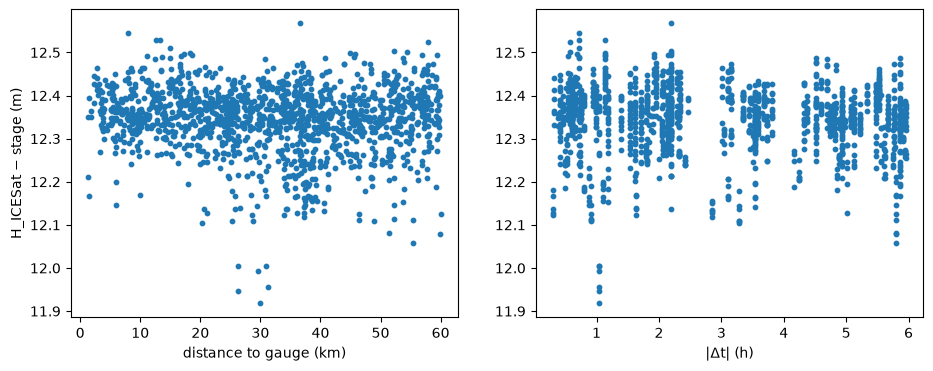

In [4]:
pre = m[m['period'] == 'PRE_BREACH']
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].scatter(pre['distance_to_gauge_km'], pre['alignment_residual_m'], s=10)
ax[0].set_xlabel('distance to gauge (km)'); ax[0].set_ylabel('H_ICESat − stage (m)')
ax[1].scatter(pre['time_difference_hours'], pre['alignment_residual_m'], s=10)
ax[1].set_xlabel('|Δt| (h)')